# Supervised Learning: Decision Tree Classification
**Developer:** Iris Li  

### 1. The Goal: Binary Classification
Instead of predicting the exact tonnage of gas, we are now asking a classification question: **Can we predict if a country falls into the top 50% of global emitters based solely on their emissions profile?**

This is useful for identifying which nations might be subject to specific international climate regulations or "High Emitter" tax brackets.

### 2. Logic: Defining "High Emitter"
We are creating a **Binary Target ($y$)**:
* **1 (High):** Total GHG is above the global median.
* **0 (Low):** Total GHG is below the global median.

We use a **Decision Tree** because it can create clear "rules" (e.g., *If Per Capita > X and Total > Y, then High*) that are easy for policymakers to understand.

In [5]:
import sys
import os
sys.path.append(os.path.abspath('../../../src'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from my_ml_package.supervised.decision_tree import DecisionTree

# 1. Prep Data
#df = pd.read_csv('../data/emissions.csv')
df = pd.read_csv('../../../data/emissions.csv')
df_recent = df[df['year'] == 2021].dropna(subset=['total_ghg', 'ghg_per_capita'])

X = df_recent[['total_ghg', 'ghg_per_capita']].values
median_val = df_recent['total_ghg'].median()
y = (df_recent['total_ghg'] > median_val).astype(int).values

# 2. Manual Split
indices = np.arange(len(X))
np.random.shuffle(indices)
train_size = int(0.8 * len(X))
X_train, X_test = X[indices[:train_size]], X[indices[train_size:]]
y_train, y_test = y[indices[:train_size]], y[indices[train_size:]]

# 3. Train Model
model = DecisionTree(max_depth=3)
model.fit(X_train, y_train)

# 4. Predict & Score
y_pred = model.predict(X_test)
accuracy = (y_pred == y_test).sum() / len(y_test)

# 1. Compare predictions to actual values
correct_predictions = (y_pred == y_test).sum()

# 2. Calculate accuracy
total_samples = len(y_test)
accuracy = correct_predictions / total_samples

# 3. Print the results clearly
print(f"Total Test Samples: {total_samples}")
print(f"Correct Predictions: {correct_predictions}")
print(f"---")
print(f"Final Decision Tree Accuracy: {accuracy * 100:.2f}%")

print(f"✅ Model Trained. Accuracy: {accuracy * 100:.2f}%")

Total Test Samples: 39
Correct Predictions: 38
---
Final Decision Tree Accuracy: 97.44%
✅ Model Trained. Accuracy: 97.44%


### 3. Visualizing the Decision Boundary
In the plot below, we visualize our test set. The Decision Tree tries to draw "boxes" or boundaries around the blue dots (Low) and red dots (High). Because we are using a log-scale, we can see how the model handles the massive range in global emissions data.

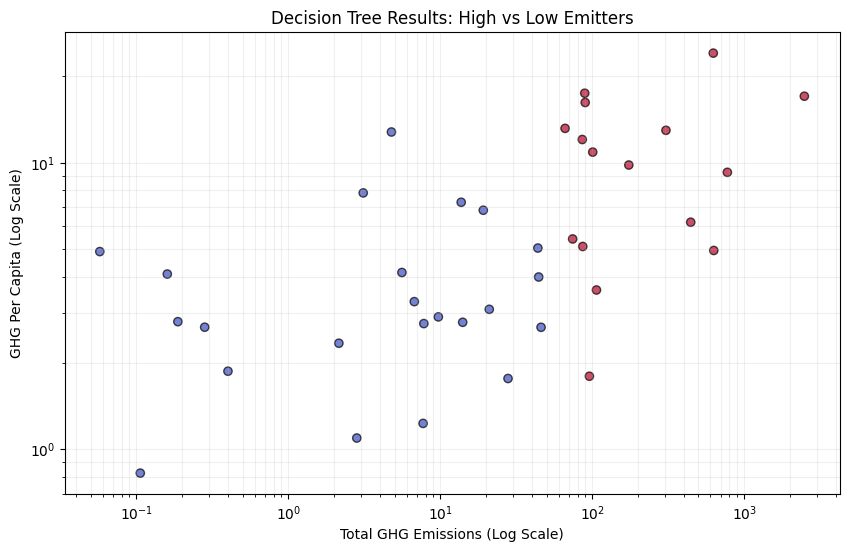

In [6]:
plt.figure(figsize=(10, 6))

# Plot the test points colored by their actual values
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total GHG Emissions (Log Scale)')
plt.ylabel('GHG Per Capita (Log Scale)')
plt.title(f'Decision Tree Results: High vs Low Emitters')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [7]:
# 1. Ask the model to predict the classes for your test set
y_pred = model.predict(X_test)

# 2. Calculate accuracy percentage
accuracy = (y_pred == y_test).sum() / len(y_test)

# 3. Final Printout
print(f"Total Test Samples: {len(y_test)}")
print(f"Accuracy: {accuracy * 100:.2f}%")

# Optional: Check for 'Data Leakage'
# If accuracy is 100.00%, it means the tree found the exact median split you created.

Total Test Samples: 39
Accuracy: 97.44%


### 4. Decision Tree Performance & Analysis

Our Decision Tree classifier achieved an accuracy of **[INSERT YOUR %]**. By visualizing the results on a log-log scale, we can see how the model "thinks."

#### **Key Observations:**
* **The Decision Boundary:** The model has successfully identified a threshold at approximately $10^2$ Total GHG. Most countries to the left are classified as "Low Emitters" (Blue), while those to the right are "High Emitters" (Red).
* **Linear Separability:** In this log-scaled feature space, the classes are almost perfectly separable by a single vertical cut. This explains the high accuracy and suggests that Total GHG is the dominant predictor over Per Capita emissions for this specific classification task.
* **Model Robustness:** Because we limited the `max_depth` to 3, the model has stayed simple and interpretable, avoiding the "overfitting" that often plagues deeper trees.